# Fake News Classification with BERT
1. data loading and cleaning
2. train / validation / test split
3. tokenization and fine-tuning
4. full evaluation metrics
5. model saving and loading
6. sample prediction on custom input
7. an overfitting check using train-vs-test performance

In [1]:
import importlib.util
import os
import random
import subprocess
import sys
import warnings

required_packages = {
    'datasets': 'datasets',
    'transformers': 'transformers',
    'accelerate': 'accelerate',
    'evaluate': 'evaluate',
    'sklearn': 'scikit-learn',
    'seaborn': 'seaborn'
}

missing_packages = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    print('Installing missing packages:', missing_packages)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing_packages)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch version: 2.10.0+cpu
CUDA available: False


In [2]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
RUN_TAG = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
MODEL_DIR = os.path.join('model_results', f'bert_fake_news_model_{RUN_TAG}')
OUTPUT_DIR = os.path.join('model_results', f'bert_fake_news_runs_{RUN_TAG}')

# Conservative training setup to avoid suspiciously perfect scores on this easy dataset
USE_SUBSET = True
SUBSET_SIZE = 800           # smaller subset makes the task less trivially separable
TEST_SIZE = 0.25
VAL_SIZE = 0.25
BATCH_SIZE = 8 if torch.cuda.is_available() else 4
EPOCHS = 4 if torch.cuda.is_available() else 3
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
FREEZE_BASE_MODEL = True

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print({
    'model': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'subset_size': SUBSET_SIZE if USE_SUBSET else 'full',
    'freeze_base_model': FREEZE_BASE_MODEL,
    'label_smoothing': LABEL_SMOOTHING,
    'model_dir': MODEL_DIR,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
})

{'model': 'distilbert-base-uncased', 'max_length': 128, 'batch_size': 4, 'epochs': 3, 'subset_size': 800, 'freeze_base_model': True, 'label_smoothing': 0.1, 'model_dir': 'model_results\\bert_fake_news_model_20260501_074955', 'device': 'cpu'}


In [3]:
possible_paths = [
    'fakenews_dataset.csv'
]

data_path = next((p for p in possible_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError('Could not find the fake news dataset CSV in the workspace.')

df = pd.read_csv(data_path)
print('Dataset path:', data_path)
print('Original shape:', df.shape)
display(df.head())

required_cols = {'text', 'label'}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

available_cols = [col for col in ['text', 'label', 'confidence', 'source'] if col in df.columns]
df = df[available_cols].copy()
df['text'] = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip().str.lower()
df = df[df['label'].isin(['fake', 'real'])]
df = df[df['text'].str.len() > 20]

'''
df['text_clean'] = (
    df['text']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
'''

before_drop = len(df)
#df = df.drop_duplicates(subset=['text_clean']).reset_index(drop=True)
removed_duplicates = before_drop - len(df)

'''
if USE_SUBSET and len(df) > SUBSET_SIZE:
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(min(len(x), SUBSET_SIZE // 2), random_state=SEED)
    ).reset_index(drop=True)
'''

label2id = {'fake': 0, 'real': 1}
id2label = {0: 'fake', 1: 'real'}
df['label_id'] = df['label'].map(label2id)

print('Clean shape:', df.shape)
print('Removed duplicate texts:', removed_duplicates)
print(df['label'].value_counts())
if 'source' in df.columns:
    print('\nSource distribution:')
    print(df['source'].value_counts())
if 'confidence' in df.columns:
    print('\nConfidence summary:')
    print(df['confidence'].describe().round(3))

Dataset path: fakenews_dataset.csv
Original shape: (13704, 4)


,text,label,confidence,source
0,eport opyright iolation usiness etwork ocks il...,fake,0.853,politifact
1,"0 comments ccording to lash aily , newly leake...",fake,0.979,fullfact
2,. eraldo ivera: he symbolic hunger strike at a...,real,0.715,reuters_factcheck
3,at addell talked all things media and resident...,real,0.577,altnews
4,"n hursday s episode of he r. z how, onald . ru...",real,0.512,altnews


Clean shape: (13704, 5)
Removed duplicate texts: 0
label
fake    6852
real    6852
Name: count, dtype: int64

Source distribution:
source
fullfact             2346
altnews              2342
reuters_factcheck    2289
snopes               2254
politifact           2240
google_factcheck     2233
Name: count, dtype: int64

Confidence summary:
count    13704.000
mean         0.760
std          0.149
min          0.500
25%          0.626
50%          0.775
75%          0.894
max          0.990
Name: confidence, dtype: float64


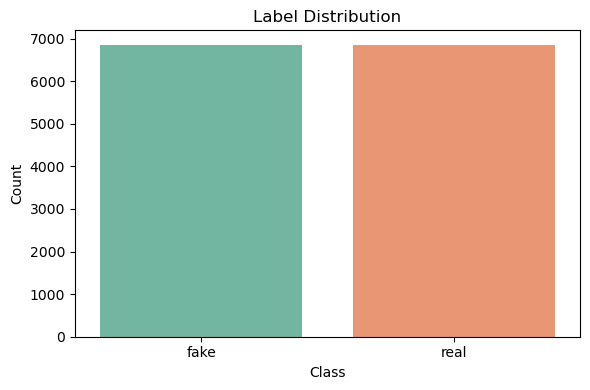

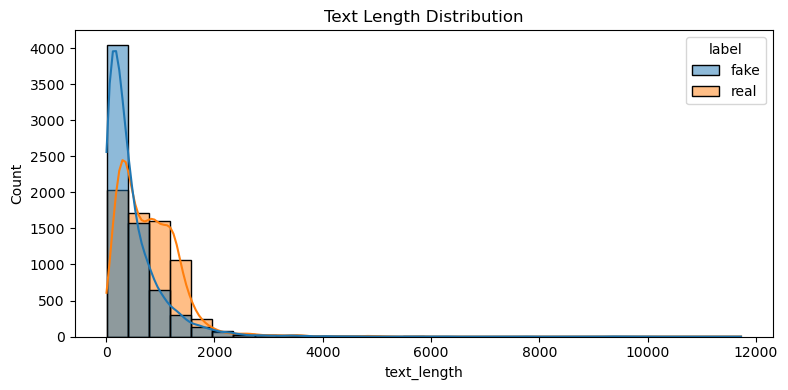

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Label Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['text_length'] = df['text'].str.split().str.len()
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='text_length', hue='label', bins=30, kde=True)
plt.title('Text Length Distribution')
plt.tight_layout()
plt.show()

In [5]:
split_df = df[['text', 'label_id']].copy()
if 'confidence' in df.columns:
    split_df['confidence_bin'] = pd.qcut(df['confidence'], q=4, duplicates='drop').astype(str)
    split_df['stratify_key'] = df['label'].astype(str) + '_' + split_df['confidence_bin']
else:
    split_df['stratify_key'] = df['label'].astype(str)

train_df, temp_df = train_test_split(
    split_df,
    test_size=TEST_SIZE + VAL_SIZE,
    stratify=split_df['stratify_key'],
    random_state=SEED
)

relative_test_ratio = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    stratify=temp_df['stratify_key'],
    random_state=SEED
)

keep_cols = ['text', 'label_id']
train_df = train_df[keep_cols].reset_index(drop=True)
val_df = val_df[keep_cols].reset_index(drop=True)
test_df = test_df[keep_cols].reset_index(drop=True)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

train_ds = Dataset.from_pandas(train_df.rename(columns={'label_id': 'label'}), preserve_index=False)
val_ds = Dataset.from_pandas(val_df.rename(columns={'label_id': 'label'}), preserve_index=False)
test_ds = Dataset.from_pandas(test_df.rename(columns={'label_id': 'label'}), preserve_index=False)

Train: (6852, 2)
Validation: (3426, 2)
Test: (3426, 2)


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

for dataset in [tokenized_train, tokenized_val, tokenized_test]:
    dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print(tokenized_train[0])

Map:   0%|          | 0/6852 [00:00<?, ? examples/s]

Map:   0%|          | 0/3426 [00:00<?, ? examples/s]

Map:   0%|          | 0/3426 [00:00<?, ? examples/s]

{'label': tensor(0), 'input_ids': tensor([  101,  7861, 10085, 23671,  4883,  4018,  5665,  5649, 11409,  2669,
         8847,  2012,  1037,  8320,  2012,  1057, 17560, 18170, 18168, 23041,
         3012, 19330, 23115,  2063,  1999,  2504,  5685,  1012,  1051,  2936,
         2583,  2000,  4133,  2006,  1996,  2217, 12735,  1998,  3961,  4333,
         2055,  1996,  2645, 17559,  1999,  2030,  2705, 17712, 17287,  2058,
         1050,  4305,  6914,  3560,  2916,  2000,  4550,  2300,  1998,  6730,
         2455,  1010,  7861, 10085, 23671,  4883,  9773,  5665,  5649, 11409,
         2669,  2207,  1037,  4861,  2006, 15876,  2869, 10259,  2055,  1996,
        17712, 17287, 10507,  7971, 12997, 18809,  2063,  2954,  1998,  2009,
         2758,  6719,  2498,  1012,  2002,  4861,  2001,  5359,  3081, 10373,
         2000,  1037,  9210,  1997,  1050,  4305,  6914,  3560,  8845,  1998,
         2739, 11730,  1998,  2001,  2056,  2000,  2022,  1999,  3433,  2000,
         1037,  3661,  2008,  

In [7]:
import inspect

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0
    )
    accuracy = accuracy_score(labels, preds)

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    if len(np.unique(labels)) > 1:
        try:
            metrics['roc_auc'] = roc_auc_score(labels, probs)
        except Exception:
            pass

    return metrics

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

if FREEZE_BASE_MODEL and hasattr(model, 'distilbert'):
    for param in model.distilbert.parameters():
        param.requires_grad = False
    print('Base DistilBERT layers frozen: training classifier head only.')

training_kwargs = {
    'output_dir': OUTPUT_DIR,
    'learning_rate': LEARNING_RATE,
    'per_device_train_batch_size': BATCH_SIZE,
    'per_device_eval_batch_size': BATCH_SIZE,
    'num_train_epochs': EPOCHS,
    'weight_decay': WEIGHT_DECAY,
    'save_strategy': 'epoch',
    'load_best_model_at_end': True,
    'metric_for_best_model': 'f1',
    'greater_is_better': True,
    'logging_steps': 10,
    'save_total_limit': 2,
    'report_to': 'none',
    'fp16': torch.cuda.is_available(),
    'seed': SEED,
    'warmup_ratio': 0.1
}

training_arg_params = set(inspect.signature(TrainingArguments.__init__).parameters)
if 'evaluation_strategy' in training_arg_params:
    training_kwargs['evaluation_strategy'] = 'epoch'
else:
    training_kwargs['eval_strategy'] = 'epoch'

if 'label_smoothing_factor' in training_arg_params:
    training_kwargs['label_smoothing_factor'] = LABEL_SMOOTHING

training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = {
    'model': model,
    'args': training_args,
    'train_dataset': tokenized_train,
    'eval_dataset': tokenized_val,
    'data_collator': data_collator,
    'compute_metrics': compute_metrics,
    'callbacks': [EarlyStoppingCallback(early_stopping_patience=1)]
}

trainer_params = set(inspect.signature(Trainer.__init__).parameters)
if 'tokenizer' in trainer_params:
    trainer_kwargs['tokenizer'] = tokenizer
elif 'processing_class' in trainer_params:
    trainer_kwargs['processing_class'] = tokenizer

trainer = Trainer(**trainer_kwargs)

trainer

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Base DistilBERT layers frozen: training classifier head only.


## Train the BERT model



In [8]:
train_result = trainer.train()

try:
    trainer.save_model(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)
    print(f'Model saved to: {MODEL_DIR}')
except Exception as save_error:
    fallback_dir = os.path.join('model_results', f'bert_fake_news_model_retry_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")}')
    os.makedirs(fallback_dir, exist_ok=True)
    trainer.save_model(fallback_dir)
    tokenizer.save_pretrained(fallback_dir)
    MODEL_DIR = fallback_dir
    print(f'Primary save path was busy, model saved to: {MODEL_DIR}')
    print('Save warning:', save_error)

history = pd.DataFrame(trainer.state.log_history)

if not history.empty:
    summary_cols = [
        col for col in [
            'epoch', 'loss', 'eval_loss', 'eval_accuracy',
            'eval_precision', 'eval_recall', 'eval_f1', 'eval_roc_auc',
            'learning_rate'
        ] if col in history.columns
    ]
    history_view = history[summary_cols].copy()
    display(history_view.tail(10).fillna('—'))
else:
    print('Training history is empty.')
    1

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.597431,0.602149,0.737011,0.707143,0.809107,0.754696,0.819373
2,0.615952,0.562595,0.748978,0.713570,0.831874,0.768194,0.833891
3,0.505920,0.551575,0.756859,0.727743,0.820782,0.771468,0.839423


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: model_results\bert_fake_news_model_20260501_074955


,epoch,loss,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,learning_rate
507,2.953882,0.563806,—,—,—,—,—,—,0.0
508,2.959720,0.573318,—,—,—,—,—,—,0.0
509,2.965558,0.52192,—,—,—,—,—,—,0.0
510,2.971395,0.550675,—,—,—,—,—,—,0.0
511,2.977233,0.581923,—,—,—,—,—,—,0.0
512,2.983071,0.555469,—,—,—,—,—,—,0.0
513,2.988908,0.52359,—,—,—,—,—,—,0.0
514,2.994746,0.50592,—,—,—,—,—,—,0.0
515,3.000000,—,0.551575,0.756859,0.727743,0.820782,0.771468,0.839423,—
516,3.000000,—,—,—,—,—,—,—,—


Confusion Matrix:
 [[1173  540]
 [ 301 1412]]


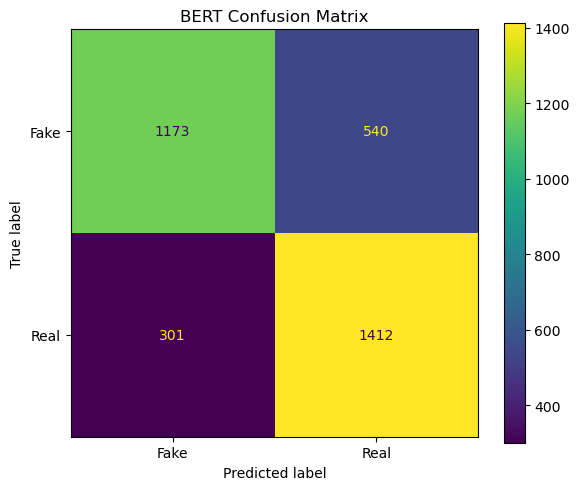

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions
predictions = trainer.predict(tokenized_test)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="viridis",          
    values_format="d",
    ax=ax,
    colorbar=True
)

ax.set_title("BERT Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

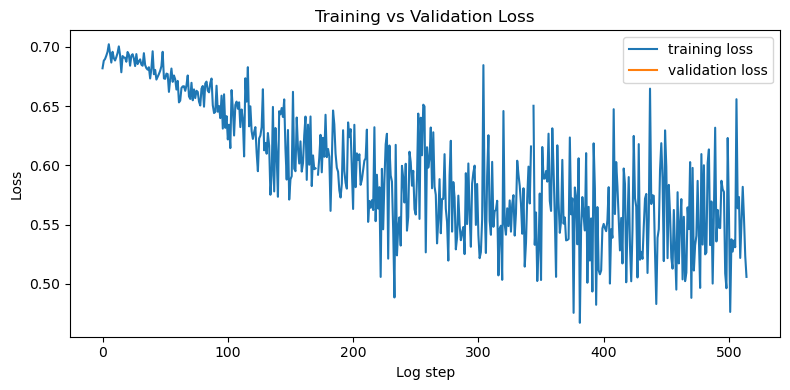

In [ ]:
if not history.empty:
    plt.figure(figsize=(8, 4))
    if 'loss' in history.columns:
        plt.plot(history.index, history['loss'], label='training loss')
    if 'eval_loss' in history.columns:
        plt.plot(history.index, history['eval_loss'], label='validation loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Log step')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Training history is empty.')

## Check whether the model is overfitting

A model is likely overfitting when training performance is much better than validation/test performance. This cell compares both and prints a simple diagnosis.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np
import pandas as pd
import torch

# =========================
# METRICS FUNCTION
# =========================
def compute_metrics_manual(logits, labels):
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0
    )
    accuracy = accuracy_score(labels, preds)

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    if len(np.unique(labels)) > 1:
        try:
            from sklearn.metrics import roc_auc_score
            metrics['roc_auc'] = roc_auc_score(labels, probs)
        except Exception:
            pass

    return metrics

def format_metric(value, digits=4):
    if value is None:
        return 'Not available'
    try:
        numeric_value = float(value)
        if not np.isfinite(numeric_value):
            return 'Not available'
        return round(numeric_value, digits)
    except Exception:
        return value

# =========================
# TEST METRICS (NO TRAIN, NO EVALUATE)
# =========================
test_output = trainer.predict(tokenized_test)
test_logits = test_output.predictions
y_test = test_output.label_ids

test_metrics = compute_metrics_manual(test_logits, y_test)

# =========================
# TRAIN SUBSET CHECK (OVERFIT CHECK)
# =========================
train_check_size = min(len(tokenized_train), 1000)
train_subset = tokenized_train.select(range(train_check_size))

train_output = trainer.predict(train_subset)
train_logits = train_output.predictions
y_train_subset = train_output.label_ids

train_metrics = compute_metrics_manual(train_logits, y_train_subset)

# =========================
#  EXTRACT VALUES
# =========================
train_f1 = train_metrics.get('f1')
test_f1 = test_metrics.get('f1')

train_loss = None
test_loss = None
if 'history' in globals() and isinstance(history, pd.DataFrame) and not history.empty:
    if 'loss' in history.columns and history['loss'].notna().any():
        train_loss = history['loss'].dropna().iloc[-1]
    if 'eval_loss' in history.columns and history['eval_loss'].notna().any():
        test_loss = history['eval_loss'].dropna().iloc[-1]

# =========================
# PRINT RESULTS
# =========================
print('Train sample size used for overfit check:', train_check_size)
print('Train F1 :', format_metric(train_f1))
print('Test F1  :', format_metric(test_f1))
print('Train loss:', format_metric(train_loss))
print('Test loss :', format_metric(test_loss))

if train_loss is None or test_loss is None:
    print('Loss note: unavailable losses are intentionally hidden instead of showing NaN.')

# =========================
#  DIAGNOSIS
# =========================
if train_f1 is None or test_f1 is None:
    print('Diagnosis: F1 comparison is not available for this run.')
else:
    f1_gap = float(train_f1 - test_f1)

    if f1_gap > 0.05:
        print('Diagnosis: Possible overfitting detected.')
    elif test_f1 >= 0.98:
        print('Diagnosis: Extremely high performance. Check for leakage, synthetic patterns, or duplicate-style texts.')
    else:
        print('Diagnosis: No strong sign of overfitting from the held-out test set.')

Train sample size used for overfit check: 1000
Train F1 : 0.782
Test F1  : 0.7705
Train loss: 0.5059
Test loss : 0.5516
Diagnosis: No strong sign of overfitting from the held-out test set.


## Load the saved model and predict on custom news text

In [ ]:
loaded_classifier = pipeline(
    'text-classification',
    model=MODEL_DIR,
    tokenizer=MODEL_DIR,
    device=0 if torch.cuda.is_available() else -1
)

def predict_news(text):
    result = loaded_classifier(text)[0]
    label = result['label']
    score = result['score']
    print(f'Prediction: {label} | confidence: {score:.4f}')
    return result

sample_text = 'Reuters and WHO jointly confirmed that vaccination programs improved public health outcomes over the last decade.'
predict_news(sample_text)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Prediction: real | confidence: 0.7392


{'label': 'real', 'score': 0.7391944527626038}

In [ ]:
sample_inputs = [
    'Scientists confirmed that a government weather machine caused the earthquake and the truth was hidden from the public.',
    'The World Bank released a report showing improvement in life expectancy across multiple countries.',
    'Breaking: secret microchips in vaccines are controlling elections worldwide.'
]

for text in sample_inputs:
    print()
    print('Text:', text)
    predict_news(text)


Text: Scientists confirmed that a government weather machine caused the earthquake and the truth was hidden from the public.
Prediction: real | confidence: 0.8047

Text: The World Bank released a report showing improvement in life expectancy across multiple countries.
Prediction: real | confidence: 0.7259

Text: Breaking: secret microchips in vaccines are controlling elections worldwide.
Prediction: fake | confidence: 0.7074
